# Notebook 03: Baseline Models

Trains and evaluates the two baseline models on the final 32-feature set
from notebook 02: Linear Regression and Random Forest.

Purpose: establish a performance floor before the deep learning models in
notebook 04. Any LSTM/GRU/TCN/attention model that cannot beat these
baselines has failed to learn anything the simpler models could not.

In [2]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from src.data_preprocessing import load_data, scale_data
from src.model import get_model
from src.train import train_sklearn_model, evaluate_model, compare_models, save_sklearn_model

pd.set_option("display.max_columns", None)

## 1. Load engineered data and final feature list

Loads the train/test CSVs and selected feature list saved at the end of
notebook 02, rather than recomputing engineering here - keeps this notebook
focused on modeling only.

In [3]:
train_df = pd.read_csv("../data/processed/train_engineered.csv", index_col=0, parse_dates=True)
test_df = pd.read_csv("../data/processed/test_engineered.csv", index_col=0, parse_dates=True)

with open("../data/processed/selected_features.txt", "r") as f:
    selected_features = f.read().splitlines()

print(f"Train: {train_df.shape}, Test: {test_df.shape}")
print(f"Final feature count: {len(selected_features)}")

/var/folders/_x/05s1mgk171vd_snfhp0tsfyr0000gn/T/ipykernel_91721/140868758.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df = pd.read_csv("../data/processed/train_engineered.csv", index_col=0, parse_dates=True)


Train: (15672, 51), Test: (3919, 51)
Final feature count: 32


/var/folders/_x/05s1mgk171vd_snfhp0tsfyr0000gn/T/ipykernel_91721/140868758.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_df = pd.read_csv("../data/processed/test_engineered.csv", index_col=0, parse_dates=True)


## 2. Scale features and target

Re-fits the scalers here on train_df/test_df rather than reusing the
notebook 02 pickles directly, so this notebook is runnable standalone.
Both approaches are equivalent since train_df/test_df are unchanged since
notebook 02 saved them.

In [4]:
X_train, X_test, y_train, y_test, feature_scaler, target_scaler = scale_data(
    train_df, test_df, selected_features, target_col="Appliances"
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (15672, 32), X_test: (3919, 32)


## 3. Linear Regression baseline

Simplest possible baseline. No hyperparameters to tune, so this cell also
serves as a sanity check that the data pipeline end-to-end is correct
before moving to more complex models.

In [5]:
lr_model = get_model("linear_regression")
lr_model = train_sklearn_model(lr_model, X_train, y_train)

lr_results = evaluate_model(lr_model, X_test, y_test, target_scaler=target_scaler, model_name="Linear Regression")
lr_results

{'model': 'Linear Regression',
 'MAE': 13.5083,
 'RMSE': 21.3023,
 'MAPE': 17.6123,
 'R2': 0.696}

## 4. Random Forest baseline

Non-linear baseline. Same n_estimators=200, random_state=42 used for
feature selection in notebook 02, kept consistent for comparability.

In [6]:
rf_model = get_model("random_forest", n_estimators=200, random_state=42)
rf_model = train_sklearn_model(rf_model, X_train, y_train)

rf_results = evaluate_model(rf_model, X_test, y_test, target_scaler=target_scaler, model_name="Random Forest")
rf_results

{'model': 'Random Forest',
 'MAE': 16.5427,
 'RMSE': 23.183,
 'MAPE': 21.9287,
 'R2': 0.64}

## 5. Baseline comparison table

In [7]:
baseline_comparison = compare_models([lr_results, rf_results])
baseline_comparison

,model,MAE,RMSE,MAPE,R2
0,Linear Regression,13.5083,21.3023,17.6123,0.696
1,Random Forest,16.5427,23.1830,21.9287,0.640


Linear Regression wins on every metric (RMSE 21.30 vs 23.18, R2 0.696 vs
0.640). Makes sense - Appliances_lag1 dominates importance (~0.55) and its
relationship to the target is close to linear, while Random Forest's
default depth likely overfits the remaining 31 features. Baseline to beat
in notebook 04: RMSE 21.30, R2 0.696.

## 6. Residual check

Quick scatter of predicted vs actual for the stronger baseline, to catch
any obvious systematic bias before moving to Phase 4. Full residual
diagnostics (histogram, residual vs time) are saved for notebook 05 once
all 7 models exist and can be compared together.

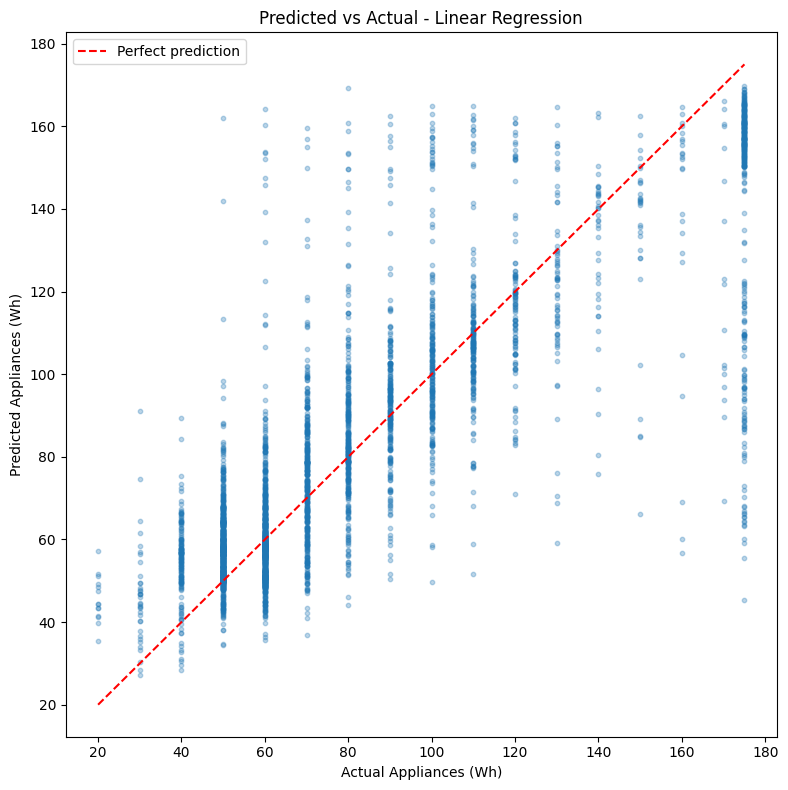

In [8]:
best_model = rf_model if rf_results["RMSE"] < lr_results["RMSE"] else lr_model
best_name = rf_results["model"] if rf_results["RMSE"] < lr_results["RMSE"] else lr_results["model"]

y_pred_scaled = best_model.predict(X_test)
y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.3, s=10)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "r--", label="Perfect prediction")
plt.xlabel("Actual Appliances (Wh)")
plt.ylabel("Predicted Appliances (Wh)")
plt.title(f"Predicted vs Actual - {best_name}")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/11_baseline_predicted_vs_actual.png", dpi=150)
plt.show()

Tracks well in the 50-120 Wh mid-range where most data sits. Overpredicts
at the low end (~20-40 Wh), underpredicts at the high end (150+ Wh) - a
direct effect of the target's right skew. Huber loss in notebook 04 should
help the high end specifically, since it handles large residuals
differently than MSE.

## 7. Save baseline models and results

In [9]:
save_sklearn_model(lr_model, "../models/linear_regression.pkl")
save_sklearn_model(rf_model, "../models/random_forest.pkl")

baseline_comparison.to_csv("../reports/baseline_results.csv", index=False)

print("Saved baseline models and results.")

Saved baseline models and results.


## Summary

- Two baselines trained: Linear Regression and Random Forest, on the final
  32-feature set from notebook 02
- Results saved to reports/baseline_results.csv for the final report's
  Results section
- [Interpretation of which baseline performed better and by how much, to
  fill in after running]

Next: notebooks/04_Deep_Learning.ipynb - LSTM, GRU, CNN-LSTM, TCN,
CNN-LSTM+Attention, including the sequence window hyperparameter sweep
([24, 72, 144] steps).